In [15]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Here we’re creating a dependent variable y based on a linear relationship with x and adding some noise.

Breaking it down:
3 * x - 8 → This is the true underlying equation.

Slope (m) = 3

Intercept (b) = -8

Without noise, this would give us perfectly straight line values.

np.random.randn(50) generates 50 random numbers from a normal distribution (mean 0, standard deviation 1).

This is different from rand() which gives uniform random numbers between 0 and 1.

* 4 → Scales the standard deviation to 4, meaning the noise will be bigger (more spread out data points).

Adding the noise: 3 * x - 8 + np.random.randn(50) * 4
This means we take the perfect line and shift each y point slightly up or down by some random amount (the noise).

In [16]:
# Generate synthetic data
x = 10 * np.random.rand(50)
y = 3 * x - 8 + np.random.randn(50) * 4

In [17]:
x = x.reshape(-1, 1)
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

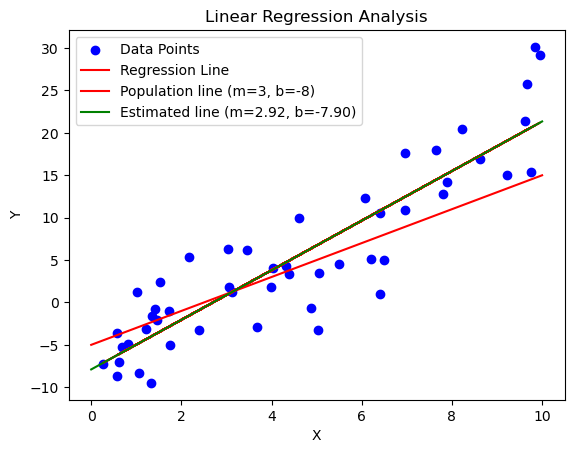

In [18]:
# plot the scatter plot and the regression line
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, y_pred, color='red', label='Regression Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Analysis')

# Plot the actual population line
x_line = np.linspace(0, 10, 100)
y_actual = 2 * x_line - 5
plt.plot(x_line, y_actual, 'r', label="Population line (m=3, b=-8)")

# Plot the estimated regression line
y_estimated = model.coef_[0] * x_line + model.intercept_
plt.plot(x_line, y_estimated, 'g', label=f"Estimated line (m={model.coef_[0]:.2f}, b={model.intercept_:.2f})")

# Add legend and show the plot
plt.legend()
plt.show()

1. Overall Model Fit
Metric	Meaning	Interpretation for your results
Dep. Variable	The variable being predicted.	Sales → this is what the regression is trying to explain.
R-squared = 0.897	Proportion of variance in Sales explained by TV, Radio, Newspaper.	89.7% of the variation in sales is explained by the model — very strong fit.
Adj. R-squared = 0.896	Like R², but adjusts for number of predictors to prevent overfitting.	Almost the same as R², so adding predictors didn’t harm the model’s efficiency.
F-statistic = 570.3, Prob(F-statistic) = 1.58e-96	Tests if all coefficients are zero.	Extremely small p-value → at least one predictor has a real, significant effect.

2. Coefficients Table
| Predictor | Coefficient (coef) | Meaning | p-value (P>|t|) | Significance? |
|-----------|--------------------|---------|-----------------|---------------|
| const | 2.9389 | Base Sales when TV, Radio, Newspaper spend = 0. | 0.000 | Yes — significantly different from 0. |
| TV | 0.0458 | Each extra $1,000 on TV ads increases sales by ~0.0458 units (holding others constant). | 0.000 | Yes — highly significant. |
| Radio | 0.1885 | Each extra $1,000 on Radio ads increases sales by ~0.1885 units. | 0.000 | Yes — highly significant. |
| Newspaper | -0.0010 | Effect is basically zero (slightly negative). | 0.860 | No — not significant; could be random noise. |

Note:

Small p-values (<0.05) mean strong evidence the coefficient is not zero.

Here, TV and Radio matter a lot; Newspaper doesn’t.

3. Confidence Intervals
[0.025, 0.975] shows the range where the true coefficient is likely to lie 95% of the time.

Example: TV’s range is [0.043, 0.049] — always positive, confirming its effect is reliably positive.

4. Residual Diagnostics
Metric	Meaning	Interpretation
Omnibus / Prob(Omnibus)	Tests residual normality.	p ≈ 0 → residuals are not perfectly normal, which might matter for strict statistical inference.
Jarque-Bera (JB) & Prob(JB)	Another normality test.	p ≈ 0 → confirms skew/kurtosis in residuals.
Skew = -1.327	Asymmetry in residuals.	Slight left skew.
Kurtosis = 6.332	Tail heaviness.	Heavier tails than normal distribution.
Durbin-Watson = 2.084	Autocorrelation check (0–4 scale, ~2 is ideal).	~2 → little to no autocorrelation in residuals.
Cond. No. = 454	Checks multicollinearity.	Not extremely high, but worth keeping an eye on.

In [19]:
import pandas as pd
import statsmodels.api as sm

# Load the dataset
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
data = pd.read_csv(url, index_col=0)

# Define the independent variables (add a constant for the intercept)
X = data[['TV', 'Radio', 'Newspaper']]
X = sm.add_constant(X)

# Define the dependent variable
y = data['Sales']

# Fit the model using the independent and dependent variables
model = sm.OLS(y, X).fit()

# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 11 Aug 2025   Prob (F-statistic):           1.58e-96
Time:                        00:40:18   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


np.random.seed(42) → fixes the random sequence for reproducibility.

n = 100 → 100 observations (rows).

x1 and x2 → two relevant predictors from a normal distribution 
𝑁
(
0
,
1
)
N(0,1).

irrelevant_predictors → 10 irrelevant predictors (noise, no real relation to y).

In [21]:
np.random.seed(42)
n = 100
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
irrelevant_predictors = np.random.normal(0, 1, (n, 10))


In [22]:
# Creating the target variable with some noise
y = 2 * x1 + 3 * x2 + np.random.normal(0, 1, n)


In [23]:
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


X → DataFrame with only the 2 relevant predictors.

X_with_irrelevant → same as X, but adds the 10 irrelevant predictors as extra columns.

In [24]:
X = pd.DataFrame({'x1': x1, 'x2': x2})
X_with_irrelevant = pd.concat(
    [X] + [pd.Series(irrelevant_predictors[:, i], name=f"irrelevant_{i}") for i in range(10)],
    axis=1
)

In [25]:
X.head()

,x1,x2
0,0.496714,-1.415371
1,-0.138264,-0.420645
2,0.647689,-0.342715
3,1.523030,-0.802277
4,-0.234153,-0.161286


In [27]:
X.shape, X_with_irrelevant.shape

((100, 2), (100, 12))

In [28]:
X_with_irrelevant.head()

,x1,x2,irrelevant_0,irrelevant_1,irrelevant_2,irrelevant_3,irrelevant_4,irrelevant_5,irrelevant_6,irrelevant_7,irrelevant_8,irrelevant_9
0,0.496714,-1.415371,0.357787,0.560785,1.083051,1.053802,-1.377669,-0.937825,0.515035,0.513786,0.515048,3.852731
1,-0.138264,-0.420645,0.570891,1.135566,0.954002,0.651391,-0.315269,0.758969,-0.772825,-0.236819,-0.485364,0.081874
2,0.647689,-0.342715,2.314659,-1.867265,0.686260,-1.612716,-0.471932,1.088951,0.064280,-1.077745,-0.715304,0.679598
3,1.523030,-0.802277,-0.730367,0.216459,0.045572,-0.651600,2.143944,0.633919,-2.025143,0.186454,-0.661786,0.852433
4,-0.234153,-0.161286,-0.792521,-0.114736,0.504987,0.865755,-1.200296,-0.334501,-0.474945,-0.653329,1.765454,0.404982


model1 → trained only on relevant predictors (x1, x2).

model2 → trained on both relevant and irrelevant predictors.

In [29]:
model1 = LinearRegression().fit(X, y)
model2 = LinearRegression().fit(X_with_irrelevant, y)


# Store the models for comparisions

In [30]:
models = [
    ('Model with relevant predictors', model1, X.shape[1]),
    ('Model with irrelevant predictors', model2, X_with_irrelevant.shape[1])
]


In [31]:
for name, model, k in models:
    r2 = r2_score(y, model.predict(X_with_irrelevant.iloc[:, :k]))
    adj_r2 = adjusted_r2(r2, n, k)
    print(f"{name}: R-squared = {r2:.3f}, Adjusted R-squared = {adj_r2:.3f}")



Model with relevant predictors: R-squared = 0.912, Adjusted R-squared = 0.910
Model with irrelevant predictors: R-squared = 0.919, Adjusted R-squared = 0.908


# ✅ Summary of models

Model with relevant predictors → High R² and Adjusted R² (both good).

Model with irrelevant predictors → Slightly higher R², but Adjusted R² drops → warning that extra predictors don’t add value.